# Simulate a single SEI species at a time

2026/02/04

Andrew Weng

Let's study the reaction-diffusion currents closely for a single SEI species.

Let's also separate the result generated from the reference diffusivity $D_0$ from the boosted diffusivity $D^B = D_0(1+B(t))$

The overall objective is to unpack and understand the various contributions to the initial "current surge" that we see within the first hours of the formation cycles. Without this study, it's hard to appreciate what's happening in the final result which has all of the effects (SEI diffusivity boosting, mixed reaction-diffusion kinetics, multi-species reactions) all mixed in together.

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as patches    

from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

In [2]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
# expt2, df2 = ioutils.fetch_experimental_data(152074)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

In [3]:
d_ec_opt1 = 3.665e-20
d_vc_opt1 = 3.162e-17
d_ec_opt2 = 2.7e-20
d_vc_opt2 = 5.3e-17
d_ec_opt3 = 4.924e-20
d_vc_opt3 = 3.162e-17

In [13]:
df_sim1 = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, kappa_ec=1.415e-4, kappa_vc=3.10e-5, dt=5, include_flag=1)
df_sim1_sei1 = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, kappa_ec=1.415e-4, kappa_vc=3.10e-5, dt=5, include_flag=1, sei_reactions='sei1')
df_sim1_sei2 = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, kappa_ec=1.415e-4, kappa_vc=3.10e-5, dt=5, include_flag=1, sei_reactions='sei2')
df_sim1_sei1_noboost = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, kappa_ec=1.415e-4, kappa_vc=3.10e-5, dt=5, include_flag=1, to_boost=False, sei_reactions='sei1')
df_sim2 = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, kappa_ec=1.797e-4, kappa_vc=3.10e-5, dt=5, include_flag=1)
df_sim2_sei1 = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, kappa_ec=1.797e-4, kappa_vc=3.10e-5, dt=5, include_flag=1, sei_reactions='sei1')
df_sim2_sei2 = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, kappa_ec=1.797e-4, kappa_vc=3.10e-5, dt=5, include_flag=1, sei_reactions='sei2')
df_sim2_sei1_noboost = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, kappa_ec=1.797e-4, kappa_vc=3.10e-5, dt=5, include_flag=1, to_boost=False, sei_reactions='sei1')
df_sim3 = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, kappa_ec=2.559e-4, kappa_vc=3.10e-5, dt=1, include_flag=1)
df_sim3_sei1 = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, kappa_ec=2.559e-4, kappa_vc=3.10e-5, dt=1, include_flag=1, sei_reactions='sei1')
df_sim3_sei2 = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, kappa_ec=2.559e-4, kappa_vc=3.10e-5, dt=1, include_flag=1, sei_reactions='sei2')
df_sim3_sei1_noboost = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, kappa_ec=2.559e-4, kappa_vc=3.10e-5, dt=1, include_flag=1, to_boost=False, sei_reactions='sei1')

/Users/ampere/code/formation-modeling/src/cellsim.py:303: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:302: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:303: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:303: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei2[k+1] = 1 / (1/self.j_sei_rxn2[k+1] + 1/self.j_sei_dif2[k+1])
/Users/ampere/code/formation-modeling/src/cellsim.py:302: RuntimeWarning: divide by zero encountered in scalar divide
  self.j_sei1[k+1] = 1 / (1/self.j_sei_rxn1[k+1] + 1/self.j_sei_dif1[k+1])
/Users/ampere/code/formation-modeli

In [14]:
def plot_comparison(df_orig, df_sei1, df_sei2, df_sei1_noboost, title=''):
    """
    Plot comparison of four simulation results:
    - Original (with boosting, all SEI reactions)
    - EC Only (sei1 only, still boosted)
    - VC Only (sei2 only, still boosted)
    - EC Only + No Boost (sei1 only, no boosting)
    
    Two subplots:
    - Row 1: Full cell voltage and cathode/anode potentials
    - Row 2: Full cell current with SEI1 and SEI2 currents overlayed
    """
    
    num_subplots = 2
    gridspec = dict(hspace=0.1, height_ratios=np.ones(num_subplots))
    
    fig, axs = plt.subplots(nrows=num_subplots, ncols=1,
                            figsize=(12, num_subplots * 4),
                            gridspec_kw=gridspec,
                            sharex=True)
    
    [ax.grid(False) for ax in axs]
    
    # Define line styles and labels for each case
    cases = [
        (df_orig, 'Original', '-', 1.0),
        (df_sei1, 'EC Only', '--', 0.8),
        (df_sei2, 'VC Only', '-.', 0.8),
        (df_sei1_noboost, 'EC Only + No Boost', ':', 0.6),
    ]
    
    colors = {'vt': 'k', 'cathode': 'b', 'anode': 'r', 
              'i_app': 'k', 'i_sei1': 'c', 'i_sei2': 'm'}
    
    # Row 1: Voltages and Potentials
    i = 0
    for df, label, ls, alpha in cases:
        xx = df['t'] / 3600
        axs[i].plot(xx, df['vt'], ls=ls, c=colors['vt'], alpha=alpha, label=f'$V_t$ ({label})')
        axs[i].plot(xx, df['ocv_p'] + df['eta_p'], ls=ls, c=colors['cathode'], alpha=alpha, label=f'$U^+ + \\eta^+$ ({label})')
        axs[i].plot(xx, df['ocv_n'] - df['eta_n'], ls=ls, c=colors['anode'], alpha=alpha, label=f'$U^- - \\eta^-$ ({label})')
    
    axs[i].axhline(y=0.80, ls='--', c='c', lw=0.8, label=r'$U_{\mathrm{EC}}$ = 0.80V')
    axs[i].axhline(y=1.35, ls='--', c='m', lw=0.8, label=r'$U_{\mathrm{VC}}$ = 1.35V')
    axs[i].set_ylabel('Voltage/Potential [V]')
    axs[i].set_ylim((0.0, 4.5))
    axs[i].legend(loc='upper right', fontsize=7, ncol=4)
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    
    # Row 2: Currents
    i = 1
    for df, label, ls, alpha in cases:
        xx = df['t'] / 3600
        axs[i].plot(xx, df['i_app'], ls=ls, c=colors['i_app'], alpha=alpha, label=f'$I_{{app}}$ ({label})')
        axs[i].plot(xx, df['i_sei1'], ls=ls, c=colors['i_sei1'], alpha=alpha, label=f'$I_{{EC}}$ ({label})')
        axs[i].plot(xx, df['i_sei2'], ls=ls, c=colors['i_sei2'], alpha=alpha, label=f'$I_{{VC}}$ ({label})')
    
    axs[i].axhline(y=0, ls='-', c='k', lw=0.5)
    axs[i].set_ylabel('Current [A]')
    axs[i].set_xlabel('Time [hrs]')
    axs[i].set_ylim((-0.05, 0.35))
    axs[i].legend(loc='upper right', fontsize=7, ncol=4)
    
    plt.tight_layout()
    
    return fig, axs

/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_6047/169888529.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


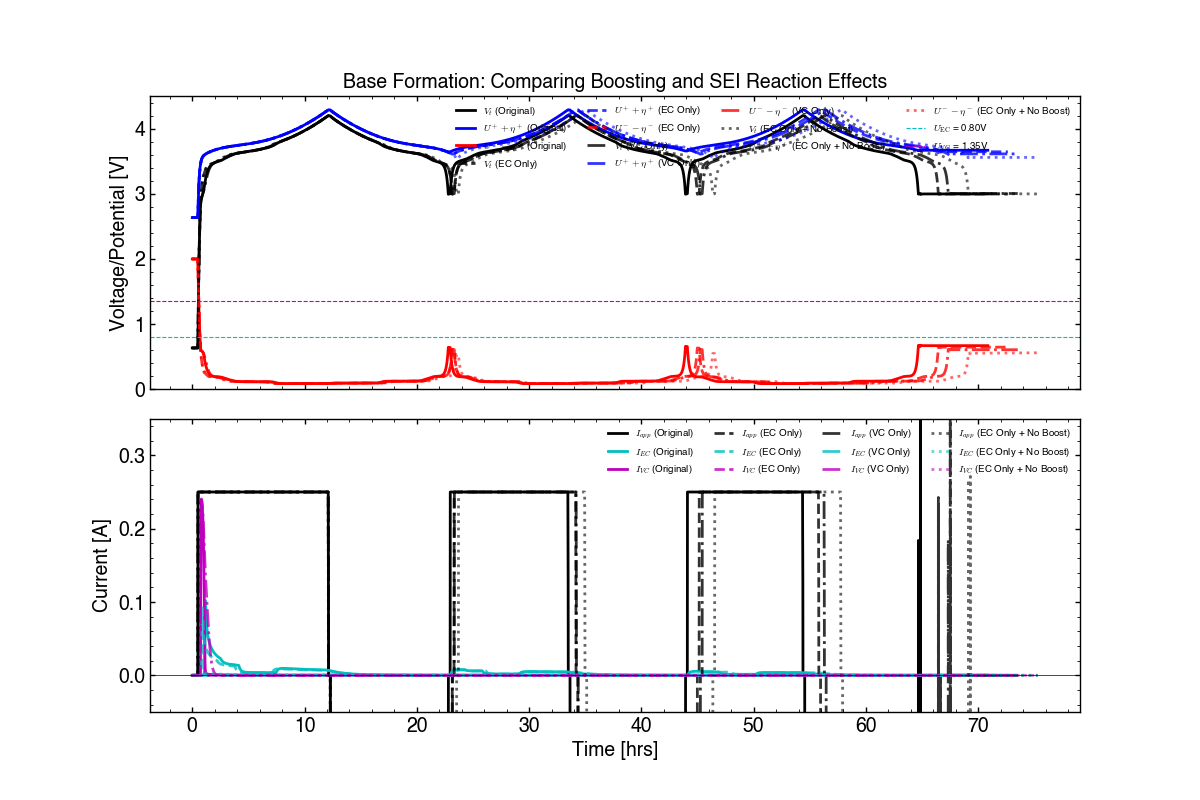

In [15]:
# Plot Base Formation comparison
fig1, axs1 = plot_comparison(df_sim1, df_sim1_sei1, df_sim1_sei2, df_sim1_sei1_noboost, 
                              title='Base Formation: Comparing Boosting and SEI Reaction Effects')

/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_6047/169888529.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


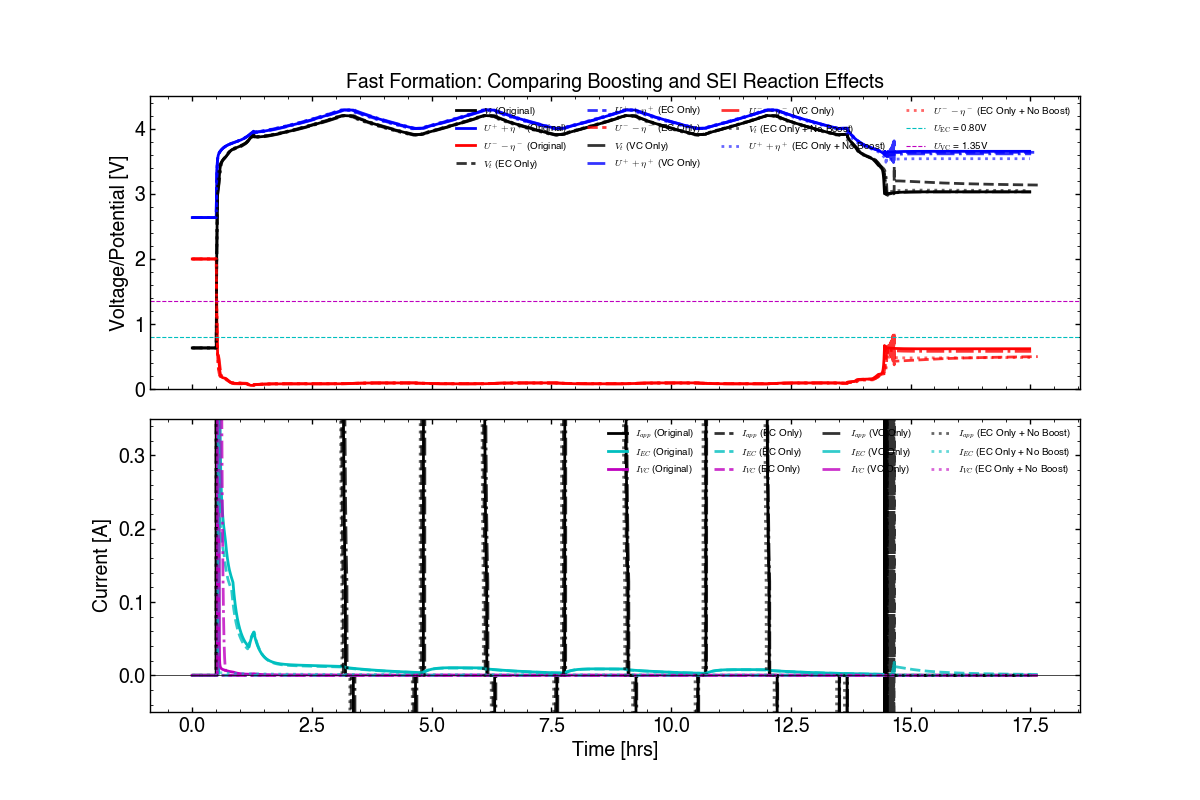

In [17]:
# Plot Fast Formation comparison
fig2, axs2 = plot_comparison(df_sim2, df_sim2_sei1, df_sim2_sei2, df_sim2_sei1_noboost,
                              title='Fast Formation: Comparing Boosting and SEI Reaction Effects')

/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_6047/2588669838.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


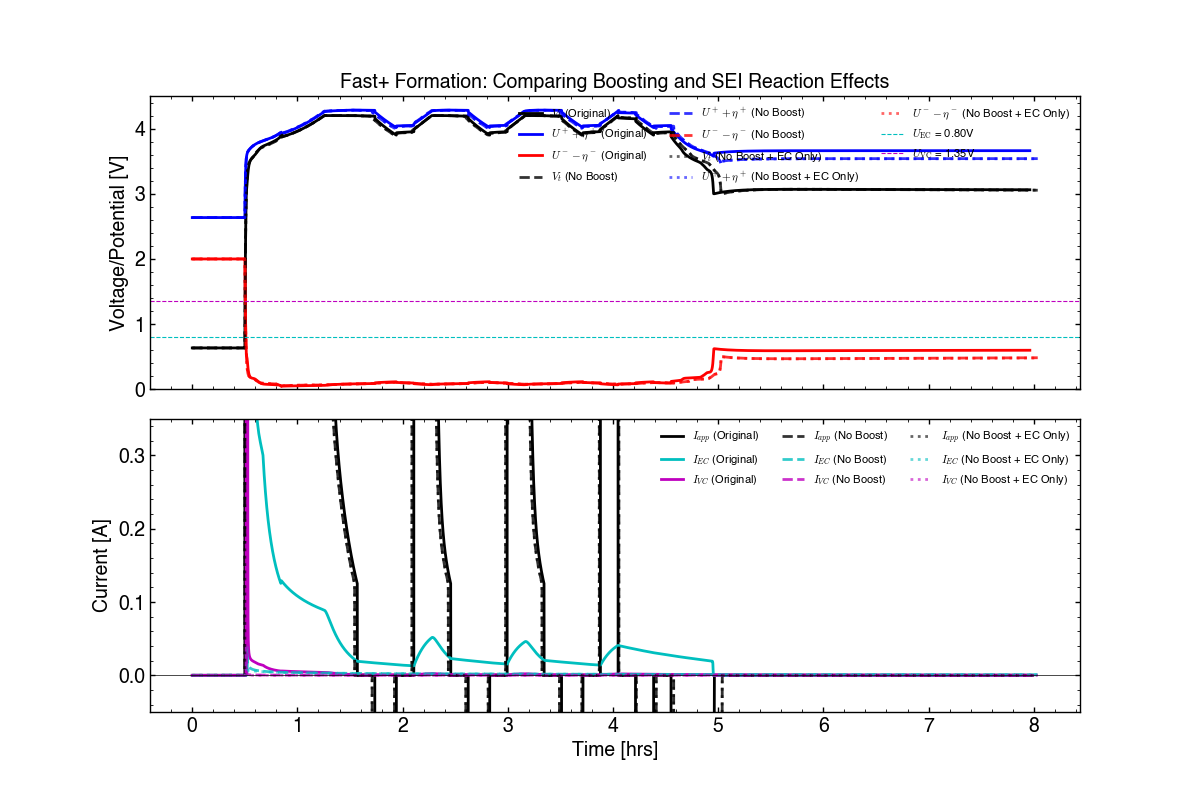

In [8]:
# Plot Fast+ Formation comparison
fig3, axs3 = plot_comparison(df_sim3, df_sim3_sei1, df_sim3_sei2, df_sim3_sei1_noboost,
                              title='Fast+ Formation: Comparing Boosting and SEI Reaction Effects')